## VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool optimised for short, clause-level text. It requires no training data and returns four scores per input: positive, negative, neutral, and a normalised compound score ranging from -1 (most negative) to +1 (most positive). This section applies VADER to all 452,364 labelled sentences, aggregates scores to document level, tests whether sentiment differs significantly between Confusing and Clear documents, and visualises the findings.

In [1]:
# Install the vaderSentiment library if not already present
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "vaderSentiment"], check=True)

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import mannwhitneyu
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print(f"All libraries imported successfully.")

All libraries imported successfully.


### Load Data and Apply VADER
Runtime warning: This cell scores 452,364 sentences one by one. Expect 3–6 minutes on a standard CPU. You will see a tqdm progress bar counting through the sentences. Do not interrupt the cell.

In [2]:
# Path to the saved sentence-level CSV produced in 01_preprocessing.ipynb
SENTENCES_PATH = r"C:\Users\HP\Downloads\archive\sentences_labelled.csv"

df_sentences = pd.read_csv(SENTENCES_PATH)
print(f"Sentences loaded: {len(df_sentences)}")

# Initialise VADER analyser — one instance is reused for all sentences
# for efficiency (avoids reloading the lexicon on every call)
analyser = SentimentIntensityAnalyzer()

# Score every sentence and collect the four VADER outputs.
# polarity_scores() returns a dict with keys: pos, neu, neg, compound
vader_results = []
for sentence in tqdm(df_sentences['sentence'], desc="Scoring sentences"):
    try:
        scores = analyser.polarity_scores(str(sentence))
        vader_results.append(scores)
    except Exception as e:
        # If a sentence fails for any reason, append neutral scores
        # so the row is preserved rather than lost
        vader_results.append({'pos': 0.0, 'neu': 1.0, 'neg': 0.0, 'compound': 0.0})

# Unpack the list of dicts into four new columns on the dataframe
vader_df = pd.DataFrame(vader_results)
df_sentences['vader_pos']      = vader_df['pos'].values
df_sentences['vader_neu']      = vader_df['neu'].values
df_sentences['vader_neg']      = vader_df['neg'].values
df_sentences['vader_compound'] = vader_df['compound'].values

print(f"VADER scoring complete.")
print(f"Mean compound score (Confusing): {df_sentences[df_sentences['label'] == 1]['vader_compound'].mean():.4f}")
print(f"Mean compound score (Clear)    : {df_sentences[df_sentences['label'] == 0]['vader_compound'].mean():.4f}")

Sentences loaded: 452364


Scoring sentences: 100%|██████████| 452364/452364 [00:51<00:00, 8830.96it/s] 


VADER scoring complete.
Mean compound score (Confusing): 0.1910
Mean compound score (Clear)    : 0.1336


### Aggregate to Document Level and Run Statistical Test

In [3]:
# Path to the document-level CSV
DOCS_PATH = r"C:\Users\HP\Downloads\archive\documents_labelled.csv"
df_docs = pd.read_csv(DOCS_PATH)

# Aggregate sentence-level VADER scores up to document level by averaging.
# This gives one compound score per document (per filename), which can then
# be compared against the document's Confusing/Clear label.
doc_vader = df_sentences.groupby('filename')[['vader_pos', 'vader_neu', 'vader_neg', 'vader_compound']].mean().reset_index()

# Merge aggregated VADER scores with document-level labels
# Using inner join — only documents present in both files are kept
df_vader_docs = pd.merge(doc_vader, df_docs[['filename', 'company', 'doc_type_clean', 'label', 'label_name']], on='filename', how='inner')

print(f"Documents after merge: {len(df_vader_docs)}")
print(f"Confusing documents  : {len(df_vader_docs[df_vader_docs['label'] == 1])}")
print(f"Clear documents      : {len(df_vader_docs[df_vader_docs['label'] == 0])}")

# Summarise mean VADER scores by label group
summary = df_vader_docs.groupby('label_name')[['vader_pos', 'vader_neu', 'vader_neg', 'vader_compound']].mean().round(4)
print(f"\nMean VADER scores by label:")
print(summary)

# Mann-Whitney U test on compound scores between Confusing and Clear documents.
# This is a non-parametric test used because we cannot assume normality
# in aggregated sentiment scores across thousands of documents.
confusing_scores = df_vader_docs[df_vader_docs['label'] == 1]['vader_compound']
clear_scores     = df_vader_docs[df_vader_docs['label'] == 0]['vader_compound']

stat, p_value = mannwhitneyu(confusing_scores, clear_scores, alternative='two-sided')

print(f"\nMann-Whitney U Test — Compound Score (Confusing vs Clear)")
print(f"  U statistic : {stat:.2f}")
print(f"  p-value     : {p_value:.6f}")

if p_value < 0.05:
    print(f"  Result      : Statistically significant difference (p < 0.05)")
else:
    print(f"  Result      : No statistically significant difference (p >= 0.05)")

Documents after merge: 4732
Confusing documents  : 2366
Clear documents      : 2366

Mean VADER scores by label:
            vader_pos  vader_neu  vader_neg  vader_compound
label_name                                                 
Clear          0.0832     0.8828     0.0340          0.1357
Confusing      0.0874     0.8771     0.0355          0.1833

Mann-Whitney U Test — Compound Score (Confusing vs Clear)
  U statistic : 3563845.50
  p-value     : 0.000000
  Result      : Statistically significant difference (p < 0.05)


### Visualisation

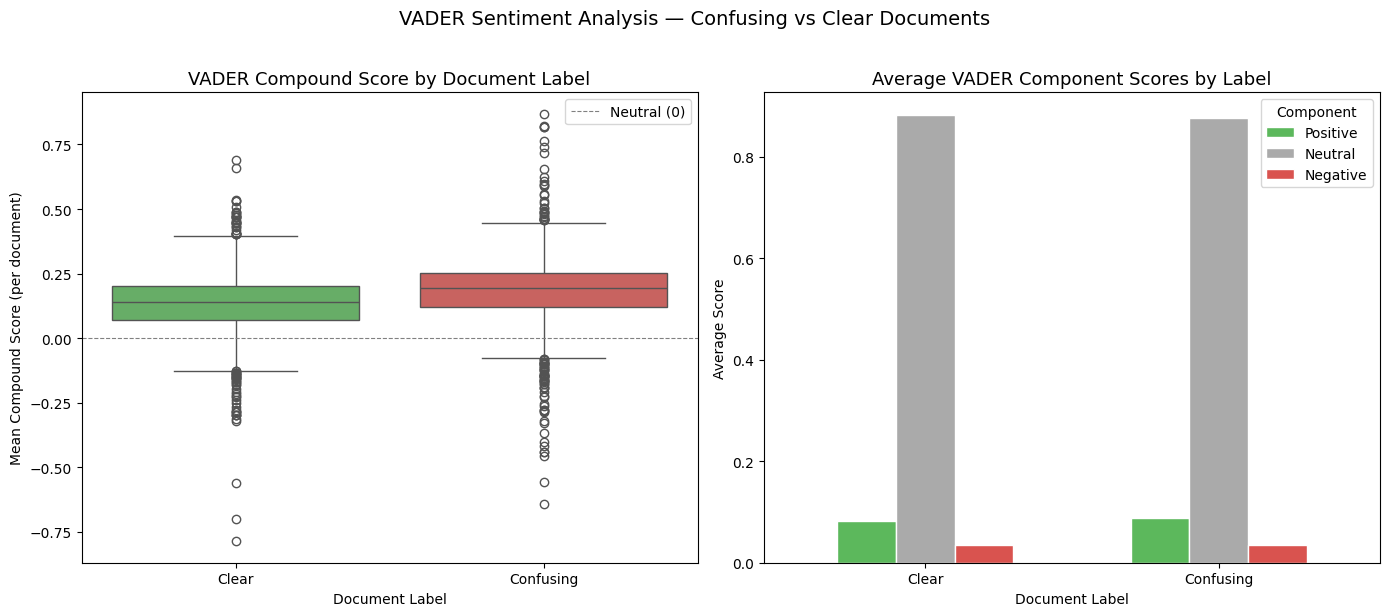

Plot saved to archive folder.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Boxplot of compound scores by label
# Shows the distribution of overall sentiment tone across document groups
sns.boxplot(
    data=df_vader_docs,
    x='label_name',
    y='vader_compound',
    hue='label_name',
    palette={'Confusing': '#d9534f', 'Clear': '#5cb85c'},
    legend=False,
    ax=axes[0]
)
axes[0].set_title('VADER Compound Score by Document Label', fontsize=13)
axes[0].set_xlabel('Document Label')
axes[0].set_ylabel('Mean Compound Score (per document)')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Neutral (0)')
axes[0].legend()

# Plot 2 — Grouped bar chart of pos / neu / neg averages by label
# Breaks down sentiment composition to show whether confusing documents
# differ in negativity, positivity, or neutrality specifically
bar_data = df_vader_docs.groupby('label_name')[['vader_pos', 'vader_neu', 'vader_neg']].mean()
bar_data.plot(
    kind='bar',
    ax=axes[1],
    color=['#5cb85c', '#aaaaaa', '#d9534f'],
    edgecolor='white',
    width=0.6
)
axes[1].set_title('Average VADER Component Scores by Label', fontsize=13)
axes[1].set_xlabel('Document Label')
axes[1].set_ylabel('Average Score')
axes[1].set_xticklabels(bar_data.index, rotation=0)
axes[1].legend(['Positive', 'Neutral', 'Negative'], title='Component')

plt.suptitle('VADER Sentiment Analysis — Confusing vs Clear Documents', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r"C:\Users\HP\Downloads\archive\vader_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to archive folder.")